***Import Library***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score

***Load Dataset***

In [2]:
df = pd.read_csv('HR_Data_MNC_Data Science Lovers.csv')

***Data Preview***

In [3]:
df.head()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype
---  ------              -----
 0   Unnamed: 0          int64
 1   Employee_ID         str  
 2   Full_Name           str  
 3   Department          str  
 4   Job_Title           str  
 5   Hire_Date           str  
 6   Location            str  
 7   Performance_Rating  int64
 8   Experience_Years    int64
 9   Status              str  
 10  Work_Mode           str  
 11  Salary_INR          int64
dtypes: int64(4), str(8)
memory usage: 359.7 MB


In [5]:
pd.options.display.float_format = '{:.4f}'.format

In [6]:
df.describe()

,Unnamed: 0,Performance_Rating,Experience_Years,Salary_INR
count,2000000.0000,2000000.0000,2000000.0000,2000000.0000
mean,999999.5000,3.0001,5.0103,896887.7557
std,577350.4135,1.4140,3.6088,402610.3044
min,0.0000,1.0000,0.0000,300000.0000
25%,499999.7500,2.0000,2.0000,616346.0000
50%,999999.5000,3.0000,5.0000,811026.5000
75%,1499999.2500,4.0000,8.0000,1073745.2500
max,1999999.0000,5.0000,15.0000,2999976.0000


***Missing & Duplicate Values Analysis***

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.duplicated(subset=df.columns.difference(['Unnamed: 0', 'Employee_ID'])).sum()

np.int64(0)

***Outlier Analysis***

In [9]:
def check_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    return df[(df[col] >= upper_limit) | (df[col] <= lower_limit)].count()

check_outlier(df, 'Salary_INR')

Unnamed: 0            69298
Employee_ID           69298
Full_Name             69298
Department            69298
Job_Title             69298
Hire_Date             69298
Location              69298
Performance_Rating    69298
Experience_Years      69298
Status                69298
Work_Mode             69298
Salary_INR            69298
dtype: int64

***Drop Unused Columns***

In [10]:
df = df.drop(columns=['Unnamed: 0', 'Employee_ID'])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column              Dtype
---  ------              -----
 0   Full_Name           str  
 1   Department          str  
 2   Job_Title           str  
 3   Hire_Date           str  
 4   Location            str  
 5   Performance_Rating  int64
 6   Experience_Years    int64
 7   Status              str  
 8   Work_Mode           str  
 9   Salary_INR          int64
dtypes: int64(3), str(7)
memory usage: 310.1 MB


***Drop Missing Values***

In [12]:
df = df.dropna().reset_index(drop=True)

***Drop Duplicate Values***

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

***Parse Hire_Date into Datetime***

In [14]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'], errors='coerce')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Full_Name           str           
 1   Department          str           
 2   Job_Title           str           
 3   Hire_Date           datetime64[us]
 4   Location            str           
 5   Performance_Rating  int64         
 6   Experience_Years    int64         
 7   Status              str           
 8   Work_Mode           str           
 9   Salary_INR          int64         
dtypes: datetime64[us](1), int64(3), str(6)
memory usage: 291.1 MB


***Drop Outliers***

In [16]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(numerical_cols)
print(categorical_cols)

['Performance_Rating', 'Experience_Years', 'Salary_INR']
['Full_Name', 'Department', 'Job_Title', 'Hire_Date', 'Location', 'Status', 'Work_Mode']


In [17]:
while check_outlier(df, 'Salary_INR')['Salary_INR'] > 0:
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        df = df[(df[col] <= upper_limit) & (df[col] >= lower_limit)]

df = df.reset_index(drop=True)

In [18]:
check_outlier(df, 'Salary_INR')

Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

***Distribution of Categorical Features***

Full_Name, Job_Title, Hire_Date, and Location are excluded to save on computing power. (If not excluded, it will take ~11 minutes to finish loading the graphs)

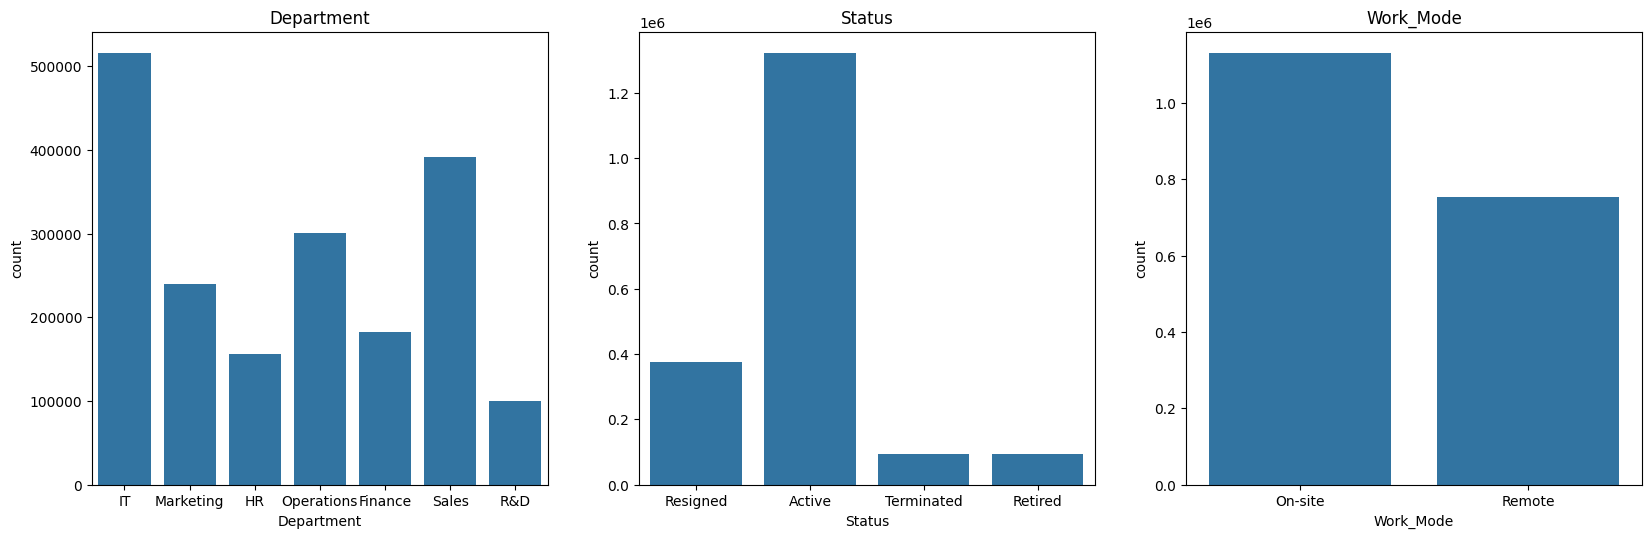

In [19]:
def univariate_categorical(df, categorical_features):
    n_columns = 3
    n_rows = -(-len(categorical_cols) // n_columns)

    plt.figure(figsize=(20, 20))

    for i,col in enumerate(categorical_features):
        plt.subplot(n_rows, n_columns, i+1)
        sns.countplot(x=col, data=df)
        plt.title(col)

    plt.show()


univariate_categorical(df, [col for col in categorical_cols if col not in ['Full_Name', 'Job_Title', 'Hire_Date', 'Location']])

***Distribution of Numerical Features***

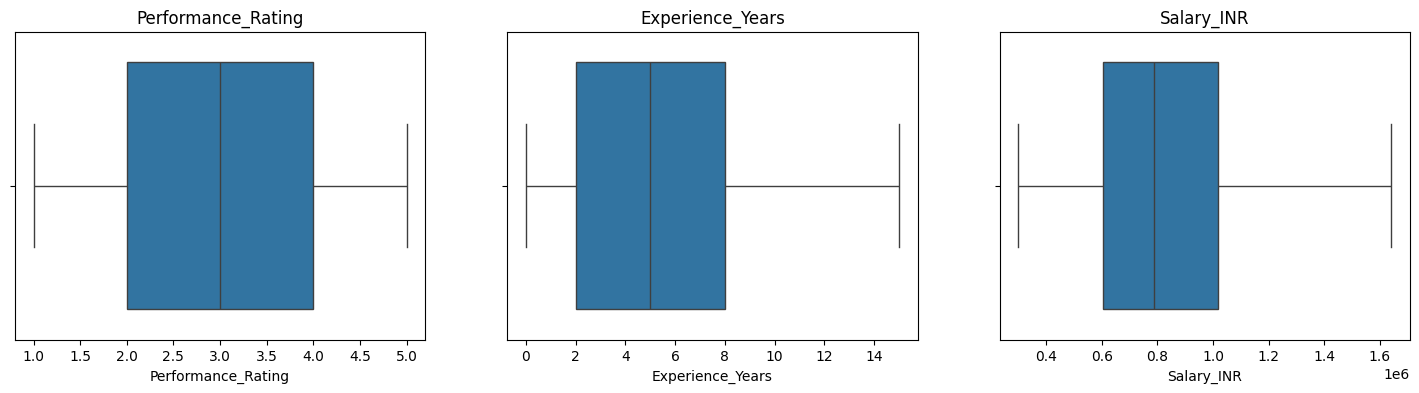

In [20]:
def univariate_numerical(df, numerical_features):
    n_columns = 3
    n_rows = -(-len(numerical_cols) // n_columns)

    plt.figure(figsize=(18, 4 * n_rows))

    for i,col in enumerate(numerical_features):
        plt.subplot(n_rows, n_columns, i+1)
        sns.boxplot(x=col, data=df)
        plt.title(col)

    plt.show()

univariate_numerical(df, numerical_cols)

***Distribution of Categorical Features vs Target***

Full_Name, Job_Title, Hire_Date, and Location are excluded to save on computing power. (If not excluded, it will take ~11 minutes to finish loading the graphs)

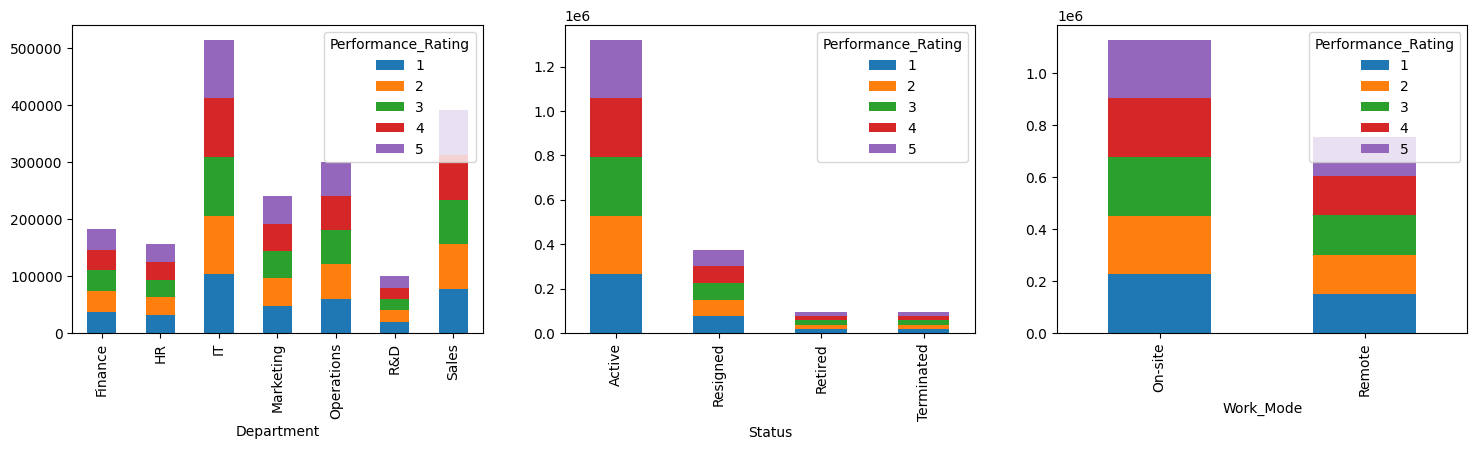

In [21]:
def check_bivariate_categorical(df, target, cols):
    n = len(cols)
    rows = -(-n // 3)
    
    plt.figure(figsize=(18, 4 * rows))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 3, i)
        
        pd.crosstab(df[col], df[target]).plot(kind='bar', stacked=True, ax=plt.gca())
        
    plt.show()

CATEGORICAL_TARGET = 'Performance_Rating'
check_bivariate_categorical(df, CATEGORICAL_TARGET, [col for col in categorical_cols if col not in ['Full_Name', 'Job_Title', 'Hire_Date', 'Location']])

***Distribution of Numerical Features vs Target***

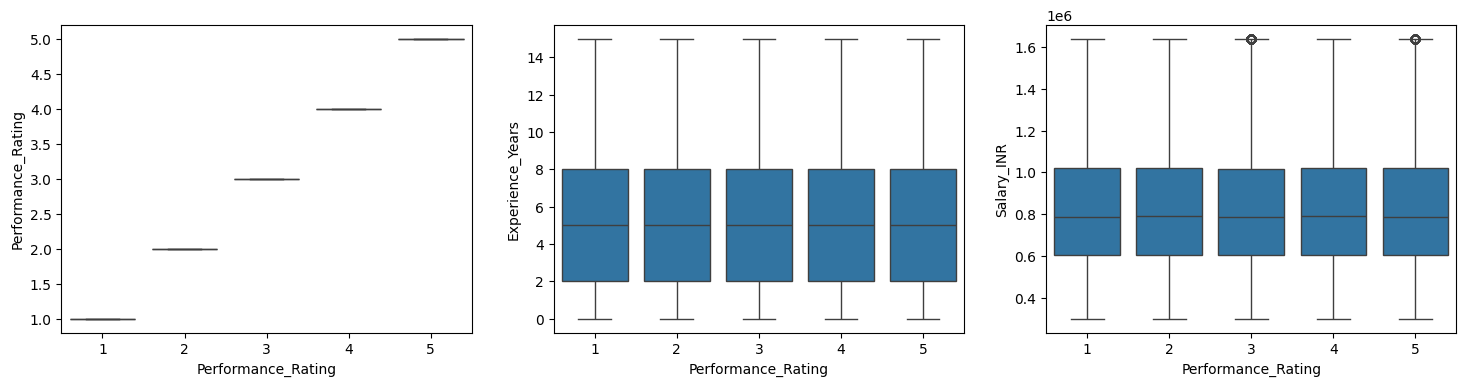

In [22]:
def check_bivariate_numerical(df, target, cols):
    n = len(cols)
    rows = -(-n // 3)
    
    plt.figure(figsize=(18, 4 * rows))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 3, i)
        
        sns.boxplot(x=target, y=col, data=df)
        
    plt.show()

CATEGORICAL_TARGET = 'Performance_Rating'
check_bivariate_numerical(df, CATEGORICAL_TARGET, numerical_cols)

***Classification***

In [23]:
clf_cols   = ['Department', 'Job_Title', 'Performance_Rating', 'Experience_Years', 'Work_Mode', 'Salary_INR']
target_col = 'Status'
df_clf     = df[clf_cols + [target_col]].copy()

le_dept = LabelEncoder()
le_job = LabelEncoder() 
le_mode = LabelEncoder() 
le_tgt = LabelEncoder()

df_clf['Department_enc'] = le_dept.fit_transform(df_clf['Department'])
df_clf['Job_Title_enc'] = le_job.fit_transform(df_clf['Job_Title'])
df_clf['Work_Mode_enc'] = le_mode.fit_transform(df_clf['Work_Mode'])
df_clf['Status_enc'] = le_tgt.fit_transform(df_clf[target_col])

X_cols = ['Department_enc', 'Job_Title_enc', 'Performance_Rating', 'Experience_Years', 'Work_Mode_enc', 'Salary_INR']
X = df_clf[X_cols].values
y = df_clf['Status_enc'].values

scaler_clf = StandardScaler()
X_scaled = scaler_clf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

print("Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=le_tgt.classes_))

Decision Tree – Employee Status Classification
              precision    recall  f1-score   support

      Active       0.70      0.97      0.81    264228
    Resigned       0.20      0.01      0.02     75107
     Retired       0.05      0.01      0.01     18834
  Terminated       0.05      0.01      0.01     18841

    accuracy                           0.69    377010
   macro avg       0.25      0.25      0.22    377010
weighted avg       0.54      0.69      0.58    377010



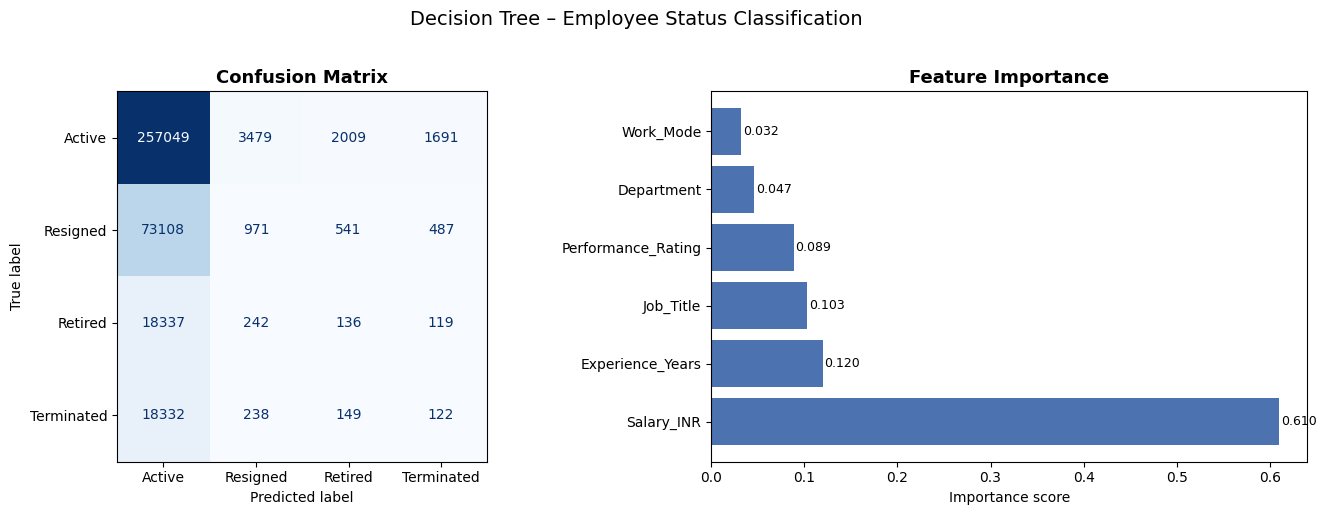

In [ ]:
# ─── DECISION TREE CLASSIFIER ─
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight={0: 1, 1: 3, 2: 8, 3: 8},
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# ─── Classification Report 
print("Decision Tree – Employee Status Classification")
print(classification_report(y_test, y_pred_dt,
      target_names=le_tgt.classes_))

# ─── Confusion Matrix + Feature Importance 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=le_tgt.classes_
)
disp_dt.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

feat_imp_dt = dt_model.feature_importances_
feat_names_dt = ['Department', 'Job_Title', 'Performance_Rating',
                 'Experience_Years', 'Work_Mode', 'Salary_INR']
sorted_idx_dt = np.argsort(feat_imp_dt)
yfeat_dt = feat_imp_dt[sorted_idx_dt]
xfeat_dt = np.array(feat_names_dt)[sorted_idx_dt]

axes[1].barh(xfeat_dt, yfeat_dt, color='#4C72B0')
axes[1].set_title('Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance score')
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, yfeat_dt):
    axes[1].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Decision Tree – Employee Status Classification', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [37]:
print(df.columns.tolist())

['Full_Name', 'Department', 'Job_Title', 'Hire_Date', 'Location', 'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode', 'Salary_INR']


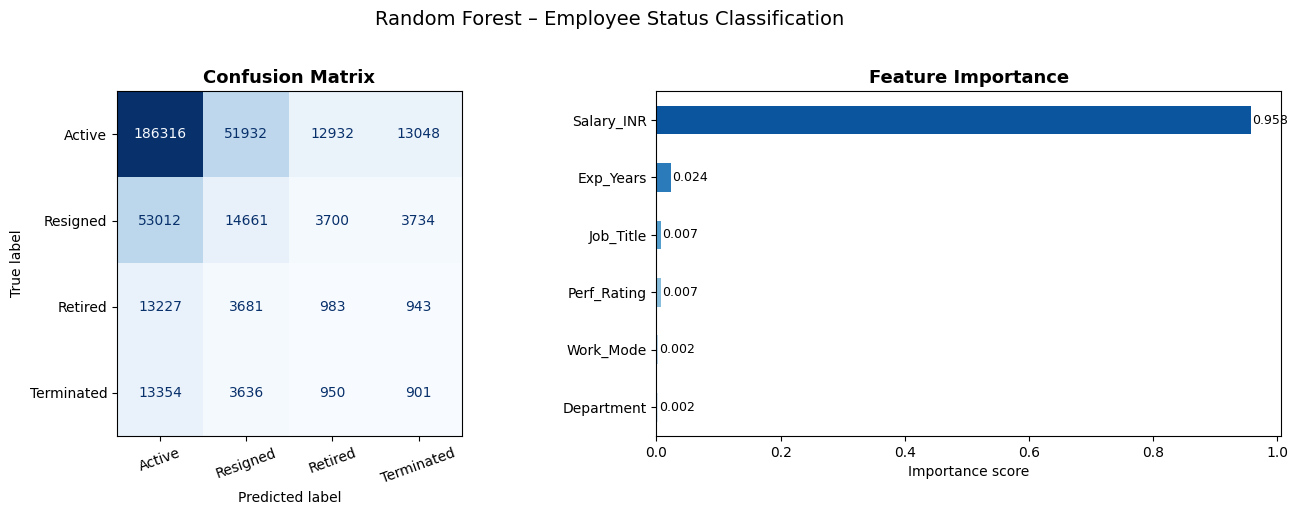

In [ ]:
yfeat_imp = pd.Series(
    rf_clf.feature_importances_,
    index=['Department','Job_Title','Perf_Rating','Exp_Years','Work_Mode','Salary_INR']
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_tgt.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

yfeat_imp.plot(kind='barh', ax=axes[1],
              color=sns.color_palette('Blues_r', len(yfeat_imp)))
axes[1].set_title('Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance score')
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, yfeat_imp):
    axes[1].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Random Forest – Employee Status Classification', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()